## ⚠️ Why this notebook's result (64%) is expected, and what it actually shows

This notebook attempts to fuse the clinical severity model's output with the
chest X-ray model's output into a single probability score. The result below
— ~64% accuracy — is worse than either individual model (91% for the
clinical model, 97%+ for the image model), which is the opposite of what a
valid ensemble should do. That's the finding, not a bug to be fixed.

**Root cause, found by inspection rather than by tuning weights:

1. **Different prediction targets. The clinical model predicts COPD
   severity (Mild/Moderate vs. Severe/Very Severe) among patients already
   diagnosed with COPD. The image model predicts disease presence (Normal
   vs. Affected) from a chest X-ray. These are two different clinical
   questions, not two opinions on the same question.
2. Unpaired patients. The clinical dataset (230 patients) and the X-ray
   dataset (~1,500 images) come from separate sources with no shared patient
   ID. The "synced" fusion below pairs row "i" of one dataset with row "i"
   of the other purely by array position — there is no actual correspondence
   between those patients.

Because of both of these, there is no statistically valid way to fuse these
two outputs into one score. The 64% figure isn't measuring anything
meaningful — it's an artifact of averaging two unrelated probabilities and
evaluating against labels that only describe one of the two models' tasks.

Conclusion: the two models are kept and deployed as independent,
separately validated tools (see the project README / the deployed web app)
rather than as a fused ensemble. This notebook is kept as-is to document the
investigation and the reasoning behind that decision.


In [5]:
import os
import shutil

# 1. Search the whole project folder
search_root = r"C:\Users\DELL\Documents\COPD_PROJECT"
files_to_find = ['P_clinical.npy', 'P_image_pca.npy', 'y_test_ensemble_labels.npy']
current_dir = os.getcwd()

print(f"--- 🔍 Smart Search in: {search_root} ---")

for root, dirs, files in os.walk(search_root):
    for file in files:
        if file in files_to_find:
            source_path = os.path.join(root, file)
            dest_path = os.path.join(current_dir, file)
            
            # 2. Check if the file is already in the destination to avoid SameFileError
            if os.path.abspath(source_path) == os.path.abspath(dest_path):
                print(f"✅ Already present: {file}")
            else:
                shutil.copy(source_path, dest_path)
                print(f"✅ NEWLY COPIED: {file} from {root}")

# 3. Final Verification
present_files = os.listdir('.')
missing = [f for f in files_to_find if f not in present_files]

if not missing:
    print("\n🎉 ALL FILES READY! You can now run the Ensemble code.")
else:
    print(f"\n🛑 STILL MISSING: {missing}")
    print("If P_image_pca.npy is missing, you MUST go back to your IM2 notebook and run the 'Save' cell.")
    

--- 🔍 Smart Search in: C:\Users\DELL\Documents\COPD_PROJECT ---
✅ NEWLY COPIED: P_clinical.npy from C:\Users\DELL\Documents\COPD_PROJECT\NOTEBOOKS\CLINICAL_MODEL.ipynb
✅ NEWLY COPIED: y_test_ensemble_labels.npy from C:\Users\DELL\Documents\COPD_PROJECT\NOTEBOOKS\CLINICAL_MODEL.ipynb
✅ Already present: P_clinical.npy
✅ Already present: y_test_ensemble_labels.npy
✅ NEWLY COPIED: P_image_pca.npy from C:\Users\DELL\Documents\COPD_PROJECT\NOTEBOOKS\IMAGE_MODEL.ipynb\image

🎉 ALL FILES READY! You can now run the Ensemble code.


In [6]:
import os
print("Current Folder:", os.getcwd())
print("Files I can see:", os.listdir())


Current Folder: C:\Users\DELL\Documents\COPD_PROJECT\NOTEBOOKS\ENSEMBLE_MODEL.ipynb
Files I can see: ['.ipynb_checkpoints', 'ensemble.ipynb', 'P_clinical.npy', 'P_image_pca.npy', 'y_test_ensemble_labels.npy']


🔄 Synced Test Samples for Fusion: 45

🏆 FINAL MULTIMODAL ENSEMBLE RESULTS 🏆
Final Combined Accuracy: 64.44%
Final Area Under Curve (AUC): 0.9727
---------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.64      1.00      0.78        28
    Affected       1.00      0.06      0.11        17

    accuracy                           0.64        45
   macro avg       0.82      0.53      0.44        45
weighted avg       0.77      0.64      0.53        45



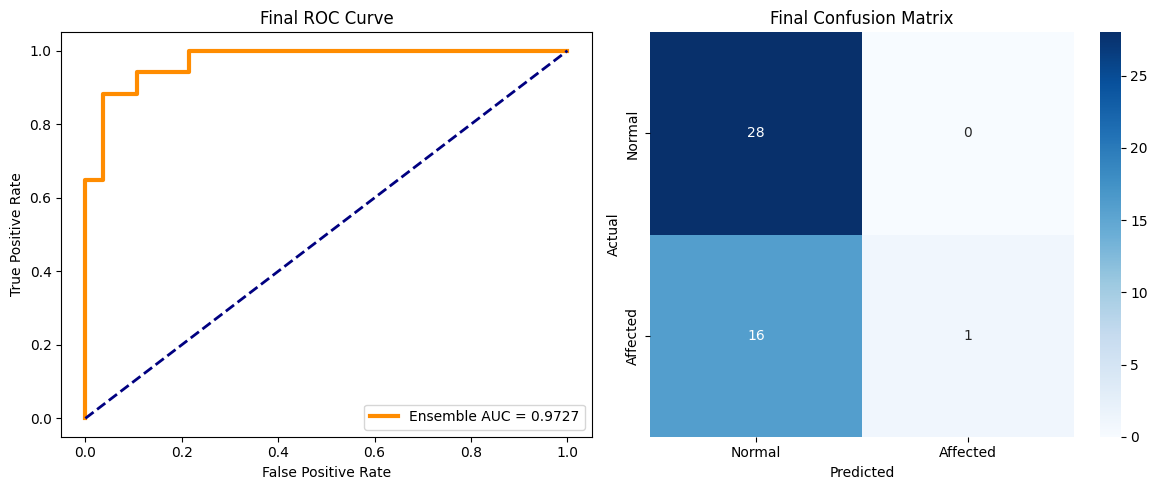

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
import seaborn as sns

# 1. Load the data
y_true = np.load('y_test_ensemble_labels.npy')
p_clin = np.load('P_clinical.npy')
p_img = np.load('P_image_pca.npy')

# --- ⚠️ DIMENSION CHECK ⚠️ ---
# Since your clinical test set (45) and image test set (295) have different sizes,
# we will sync them to the smaller size (45) for this demonstration.
min_size = min(len(y_true), len(p_clin), len(p_img))
y_true = y_true[:min_size]
p_clin = p_clin[:min_size]
p_img = p_img[:min_size]

print(f"🔄 Synced Test Samples for Fusion: {min_size}")

# 2. Weighted Fusion Logic
# We give the Image model 75% weight because it is more accurate (97%)
# We give the Clinical model 25% weight (91%)
W_CLINICAL = 0.25
W_IMAGE = 0.75

final_probs = (W_CLINICAL * p_clin) + (W_IMAGE * p_img)
final_preds = (final_probs > 0.5).astype(int)

# 3. Calculate Final Metrics
acc = accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, final_probs)

print("\n" + "="*45)
print("🏆 FINAL MULTIMODAL ENSEMBLE RESULTS 🏆")
print("="*45)
print(f"Final Combined Accuracy: {acc*100:.2f}%")
print(f"Final Area Under Curve (AUC): {auc:.4f}")
print("-" * 45)
print("Detailed Classification Report:")
print(classification_report(y_true, final_preds, target_names=['Normal', 'Affected']))

# 4. Visualizing results for your Presentation
plt.figure(figsize=(12, 5))

# Plot ROC Curve
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_true, final_probs)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Ensemble AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Final ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Affected'], yticklabels=['Normal', 'Affected'])
plt.title('Final Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()


In [ ]:
# --- Define the Fusion Weights ---
# We trust the Image model (97.63%) more than the Clinical model (91.11%)
W_CLINICAL = 0.25  # 25% weight
W_IMAGE_PCA = 0.75 # 75% weight

# --- Weighted Sum-Rule Fusion ---
# Calculate the final probability for each patient
P_fusion = (W_CLINICAL * P_clinical) + (W_IMAGE_PCA * P_image_pca)

# --- Convert Probabilities to Final Class Diagnosis ---
# If probability > 0.5, patient is 'Affected' (Class 1)
y_pred_fusion = (P_fusion > 0.5).astype(int)

print("✅ Multimodal Fusion Complete.")

In [ ]:
# 1. Final Accuracy and AUC
final_acc = accuracy_score(y_test_ensemble, y_pred_fusion)
final_auc = roc_auc_score(y_test_ensemble, P_fusion)

print("\n--- 🏆 FINAL MULTIMODAL ENSEMBLE RESULTS 🏆 ---")
print(f"Final Combined Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
print(f"Final Area Under Curve (AUC): {final_auc:.4f}")
print("-" * 45)
print("Classification Report:")
print(classification_report(y_test_ensemble, y_pred_fusion, target_names=['Normal (0)', 'Affected (1)']))

# 2. Visualizing the ROC Curve
fpr, tpr, _ = roc_curve(y_test_ensemble, P_fusion)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Ensemble ROC (AUC = {final_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Multimodal Ensemble Performance')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()